<a href="https://colab.research.google.com/github/GDVevo/ml_uni/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9612.2_%D0%93%D0%B5%D0%BE%D0%BC%D0%B0%D1%80%D0%BA%D0%B5%D1%82%D0%B8%D0%BD%D0%B3%D0%BE%D0%B2%D0%BE%D0%B5_%D0%B8%D1%81%D1%81%D0%BB%D0%B5%D0%B4%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D1%82%D0%B5%D1%80%D1%80%D0%B8%D1%82%D0%BE%D1%80%D0%B8%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа. Геомаркетинговое исследование территорий с применением методов машинного обучения**


## **Цель работы**


Овладеть методами пространственного анализа и машинного обучения для решения практической задачи определения оптимальных локаций размещения коммерческих объектов.

## **Введение**


В современном бизнесе местоположение коммерческого объекта играет ключевую роль в его успешности. Геомаркетинговый анализ позволяет объективно оценить привлекательность различных локаций, опираясь на количественные показатели и алгоритмы машинного обучения.

В рамках данной работы вы примените полный цикл пространственного анализа, включая сбор данных из открытых источников, обработку и агрегацию пространственной информации, обучение моделей машинного обучения и визуализацию результатов.

## **Задание**


Провести геомаркетинговое исследование для выбора оптимальных локаций размещения новых точек определенного типа бизнеса на территории выбранного города.

## **Порядок выполнения работы**

### **Часть 1. Подготовка данных и определение задачи**



1. **Индивидуальный выбор территории и типа бизнеса**:
   - Выберите город/район для проведения анализа (например, центральная часть Москвы, Санкт-Петербурга или любого другого крупного города)

**Ответ**: выберем город Подольск, просто потому что :)


   - Определите тип бизнеса для анализа (аптеки, продуктовые магазины, пункты выдачи заказов, рестораны определенной кухни и т.д.)

   **Ответ**: были выбраны ПВЗ Ozon (стоит сразу отметить, что у самой компании уже существует карта для подбора местоположения открытия ПВЗ. возможно, будет интересно сравнить результаты)

   - Обоснуйте свой выбор: почему данная территория и тип бизнеса интересны для анализа?

   **Ответ**: ПВЗ Ozon интересны для анализа того, например, где лучше всего будет открыть ещё один ПВЗ, как часто пользуются (если есть такая информация) уже имеющимися ПВЗ.

   Подольск может быть интересен для сотрудников Ozon из-за своей населенности, мер развития

2. **Определение ключевых факторов успешности**:
   - Самостоятельно сформулируйте не менее 5 факторов, которые могут влиять на успешность выбранного типа бизнеса

   **Ответ**:
- **Локация**. Наиболее важный пункт, насколько удобно добраться до ПВЗ, какой размер территории он может покрыть
- **Конкуренция**. Плотность пунктов в жилом массиве, необходимо выбирать локации, где поблизости нет других ПВЗ того же или конкурирующих маркетплейсов.
- **Трафик**. Находятся ли поблизости остановки, станции метро; крупные здания по типу школ, садов, офисов и т.д.
- **Площадь**. Большая площадь помещения может быть более благоприятной для ПВЗ, так как позволяет создавать более крупный склад для хранения товаров
- **Наличие поблизости парковок**. Возможно, некоторым людям всегда удобнее будет приезжать к ПВЗ. Также это позволяет людям забирать более крупные заказы на машине

   - Для каждого фактора определите, какими данными из OpenStreetMap его можно количественно описать

**Ответ**:

- *Локация*:

      building:apartments, residential
      landuse:residential
      addr:housenumber: * (подсчет количества адресов в полигоне)

- *Конкуренция*:    
  - Прямые конкуренты (ПВЗ):
        
        shop:outpost
        amenity:parcel_locker (постаматы)
        brand:Ozon, Wildberries, Yandex Market (или name:...)
  - Смежные конкуренты (почта/логистика):

        amenity:post_office
        shop:courier

- *Трафик*:

      shop:supermarket, mall
      public_transport:stop_position
      railway:station
      amenity:school, kindergarten, marketplace
      office:*

- *Площадь*:

  к сожалению, в OSM подобные данные являются редкостью, однако можно попробовать следующие теги:

        rooms:* (количество комнат; для ПВЗ желательно ≥ 2: зал выдачи + склад)
        indoor:room + room:storage (наличие выделенного склада внутри)

- *Наличие поблизости парковок*:

        amenity:parking
        parking:street_side, lane
        access:customers, public
        highway:living_street
        fee:no

   - Составьте таблицу соответствия между факторами и тегами OpenStreetMap

|Фактор|Тэг|
|-|-|
|Локация|building:apartments, residential<br>landuse:residential|
|Конкуренция|shop:outpost<br>amenity:parcel_locker<br>brand:Ozon, Wildberries, Yandex Market|
|Трафик|shop:supermarket,mall<br>amenity:marketplace<br>public_transport:stop_position<br>railway:station<br>amenity:school, kindergarten<br>office:*|
|Площадь|rooms=*<br>indoor:room + room:storage |
|Наличие парковок|amenity:parking<br>parking:street_side, lane <br>access:public<br>highway:living_street<br>fee:no|

3. **Сбор исходных данных**:
   - Настройте необходимые библиотеки из теоретического материала

In [1]:
!pip install osmnx geopandas leafmap mapclassify h3pandas h3~=3.0
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import leafmap
import osmnx as ox
from shapely.geometry import box, Polygon
from sklearn.preprocessing import MinMaxScaler
import h3
import h3pandas

INFO: pip is looking at multiple versions of h3pandas to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.4/138.4 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.5/667.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

   - Определите необходимую область интереса (ROI) с помощью интерактивной карты


In [ ]:
# не запускать это, а то сбросится выделенный прямоугольник
# m = leafmap.Map(draw_control=True, basemap='CartoDB.Positron')
# m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [ ]:
# bbox = m.user_roi_bounds()
# print(m.center)
# print(bbox)

   - Загрузите данные о существующих объектах вашего типа бизнеса и объектах инфраструктуры, связанных с выделенными вами факторами

In [2]:
ozon_gdf = ox.features_from_place("Подольск", tags={'name':'Ozon', 'brand':'Ozon'})
ozon_gdf

geometry brand brand:wikidata  \
element id                                                            
node    9076606402   POINT (37.52601 55.35784)  Ozon       Q2365235   
        9076606409    POINT (37.52271 55.4289)  Ozon       Q2365235   
        9076607465   POINT (37.54375 55.42832)  Ozon       Q2365235   
        9076607690   POINT (37.48973 55.41928)  Ozon       Q2365235   
        9076607748   POINT (37.56635 55.43924)  Ozon       Q2365235   
...                                        ...   ...            ...   
        12317955686  POINT (37.54717 55.43299)  Ozon       Q2365235   
        12317968511  POINT (37.54465 55.38238)  Ozon       Q2365235   
        12558494604  POINT (37.52876 55.41438)  Ozon       Q2365235   
        13367874811  POINT (37.53276 55.37018)   NaN            NaN   
        13367874829  POINT (37.54206 55.37328)   NaN            NaN   

                    brand:wikipedia                  contact:facebook  \
element id                                                              
node    9076606402       ru:Ozon.ru  https://www.facebook.com/ozon.ru   
        9076606409       ru:Ozon.ru  https://www.facebook.com/ozon.ru   
        9076607465       ru:Ozon.ru  https://www.facebook.com/ozon.ru   
        9076607690       ru:Ozon.ru  https://www.facebook.com/ozon.ru   
        9076607748       ru:Ozon.ru  https://www.facebook.com/ozon.ru   
...                             ...                               ...   
        12317955686      ru:Ozon.ru  https://www.facebook.com/ozon.ru   
        12317968511      ru:Ozon.ru  https://www.facebook.com/ozon.ru   
        12558494604      ru:Ozon.ru  https://www.facebook.com/ozon.ru   
        13367874811             NaN                               NaN   
        13367874829             NaN                               NaN   

                                    contact:instagram   contact:phone  \
element id                                                              
node    9076606402   https://www.instagram.com/ozonru  +7 495 2321000   
        9076606409   https://www.instagram.com/ozonru  +7 495 2321000   
        9076607465   https://www.instagram.com/ozonru  +7 495 2321000   
        9076607690   https://www.instagram.com/ozonru  +7 495 2321000   
        9076607748   https://www.instagram.com/ozonru  +7 495 2321000   
...                                               ...             ...   
        12317955686  https://www.instagram.com/ozonru  +7 495 2321000   
        12317968511  https://www.instagram.com/ozonru  +7 495 2321000   
        12558494604  https://www.instagram.com/ozonru  +7 495 2321000   
        13367874811                               NaN  +7 495 2321000   
        13367874829                               NaN  +7 495 2321000   

                                 contact:twitter           contact:vk  \
element id                                                              
node    9076606402   https://twitter.com/Ozon_ru  https://vk.com/ozon   
        9076606409   https://twitter.com/Ozon_ru  https://vk.com/ozon   
        9076607465   https://twitter.com/Ozon_ru  https://vk.com/ozon   
        9076607690   https://twitter.com/Ozon_ru  https://vk.com/ozon   
        9076607748   https://twitter.com/Ozon_ru  https://vk.com/ozon   
...                                          ...                  ...   
        12317955686  https://twitter.com/Ozon_ru  https://vk.com/ozon   
        12317968511  https://twitter.com/Ozon_ru  https://vk.com/ozon   
        12558494604  https://twitter.com/Ozon_ru  https://vk.com/ozon   
        13367874811                          NaN                  NaN   
        13367874829                          NaN                  NaN   

                          contact:website  name      opening_hours     shop  \
element id                                                                    
node    9076606402   https://www.ozon.ru/  Ozon  Mo-Su 10:00-22:00  outpost   
        9076606409    https

In [4]:
m = leafmap.Map(basemap='CartoDB.Positron')
bbox = m.user_roi_bounds()
if bbox:
    print(f"Выбранный bounding box: {bbox}")
else:
    bbox = [37.444, 55.2955, 37.6569, 55.496]
    print(f"Область не выбрана. Используем значение по умолчанию: {bbox}")
m2 = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')
m2.add_gdf(ozon_gdf, layer_name='OZON Location', info_mode='on_click')

m2

Область не выбрана. Используем значение по умолчанию: [37.444, 55.2955, 37.6569, 55.496]


Map(center=[55.39575, 37.55045], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', '…

### **Часть 2. Пространственное агрегирование и создание признаков**


1. **Создание гексагональной сетки**:
   - Самостоятельно определите оптимальную детализацию сетки H3 для вашего анализа

In [139]:
res = 9
place_name = 'Подольск'
crs_proj = "EPSG:3857"

   - Покройте территорию гексагональной сеткой выбранного разрешения

In [140]:
# 1. Получаем полигон территории
area_gdf = ox.geocode_to_gdf(place_name).to_crs("EPSG:4326")
bbox = area_gdf.total_bounds

# 2. Генерируем H3-индексы (универсальный метод, работает со всеми версиями h3)
bbox_poly = box(*bbox)
h3_ids = list(h3.polyfill_geojson(bbox_poly.__geo_interface__, res))

# 3. Создаём геометрии гексагонов из индексов
h3_geoms = [Polygon(h3.h3_to_geo_boundary(idx, geo_json=True)) for idx in h3_ids]

# 4. Собираем GeoDataFrame
h3_gdf = gpd.GeoDataFrame({'h3_index': h3_ids, 'geometry': h3_geoms}, crs="EPSG:4326")

# 5. Обрезаем по реальной границе города и переводим в метрическую проекцию
h3_gdf = h3_gdf[h3_gdf.intersects(area_gdf.unary_union)].reset_index(drop=True)
h3_gdf = h3_gdf.to_crs(crs_proj)

# 1. Переводим сетку в EPSG:4326 (широта/долгота), так как leafmap/Folium работают именно с ней
h3_gdf_viz = h3_gdf.to_crs("EPSG:4326")

# 2. Добавляем слой на ранее созданную карту m
m3 = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')

m3.add_gdf(
    h3_gdf_viz,
    layer_name="H3 Сетка (res 10)",
    info_mode="on_hover",
    style={
        "stroke": True,
        "color": "#3388ff",
        "weight": 1.5,
        "fillOpacity": 0.15,
        "fillColor": "#3388ff"
    }
)

m3

Map(center=[np.float64(55.39283315), np.float64(37.5398555)], controls=(ZoomControl(options=['position', 'zoom…

- Обоснуйте выбор разрешения (resolution) сетки с учётом масштаба вашей территории и специфики бизнеса

**Ответ**: выбранное разрешение (9, площадь ячейки=~0.11 км², ребро ~174 м) предоставляет баланс между производительностью и детализацией, затрагивает достаточно оптимальную площадь для данного анализа - она и не слишком маленькая/точная, и не слишком большая/распространенная

2. **Инженерия пространственных признаков**:
   - Определите радиусы для анализа ближнего и среднего окружения (могут отличаться от предложенных в теории в зависимости от специфики вашего бизнеса)

**Ответ**:
- Радиус 300 м (~5 мин. пешком): оценка доступности вблизи жилых домой, для более быстрого доступа к ПВЗ
- Радиус 600 м (~10 мин. пешком): оценка доступности в зонах, где затруднительно где-либо расположить ПВЗ, но всё ещё в относительной близости к жилым домам


Разработайте и реализуйте не менее 10 пространственных признаков, описывающих характеристики каждой ячейки

In [93]:
#1
own_buildings_nearby_gdf = ox.features_from_place(place_name, tags={'name':'Ozon', 'brand':'Ozon'})
own_buildings_nearby_gdf = own_buildings_nearby_gdf.to_crs(crs_proj)
#2
competitors_gdf = ox.features_from_place(place_name, tags={'brand':['Wildberries', 'Yandex.market', 'Yandex Market'],
                                                           'name':['Wildberries', 'Yandex.market', 'Yandex Market'],
                                                           'amenity':'post_office', 'shop':'courier'})
competitors_gdf = competitors_gdf.to_crs(crs_proj)
#3
shops_nearby_gdf = ox.features_from_place(place_name, tags={'shop':['supermarket', 'mall'], 'amenity':'marketplace'})
shops_nearby_gdf = shops_nearby_gdf.to_crs(crs_proj)
#4
houses_gdf = ox.features_from_place(place_name, tags={'building':['apartments', 'residential']})
houses_gdf = houses_gdf.to_crs(crs_proj)
#5
public_transport_gdf = ox.features_from_place(place_name, tags={'public_transport':'stop_position', 'railway':'station'})
public_transport_gdf = public_transport_gdf.to_crs(crs_proj)
#6
public_transport_nearby_gdf = ox.features_from_place(place_name, tags={'public_transport':'stop_position', 'railway':'station'})
public_transport_nearby_gdf = public_transport_nearby_gdf.to_crs(crs_proj)
#7
parcel_locker_gdf = ox.features_from_place(place_name, tags={'amenity':'parcel_locker'})
parcel_locker_gdf = parcel_locker_gdf.to_crs(crs_proj)
#8
parcel_locker_nearby_gdf = ox.features_from_place(place_name, tags={'amenity':'parcel_locker'})
parcel_locker_nearby_gdf = parcel_locker_nearby_gdf.to_crs(crs_proj)
#9
buildings_gdf = ox.features_from_place(place_name, tags={'amenity':['school', 'kindergarten'], 'office':'*'})
buildings_gdf = buildings_gdf.to_crs(crs_proj)
#10
buildings_nearby_gdf = ox.features_from_place(place_name, tags={'amenity':['school', 'kindergarten'], 'office':'*'})
buildings_nearby_gdf = buildings_nearby_gdf.to_crs(crs_proj)

**Дополнительное задание**: придумайте и реализуйте не менее 2 пространственных признаков, которых нет в теоретическом материале

In [12]:
#1
landuse_gdf = ox.features_from_place(place_name, tags={"landuse": "residential"})
landuse_gdf = landuse_gdf.to_crs(crs_proj)
#2
parking_nearby_gdf = ox.features_from_place(place_name, tags={'amenity':'parking', 'parking':['street_side', 'lane']})
parking_nearby_gdf = parking_nearby_gdf.to_crs(crs_proj)

3. **Анализ полученных признаков**:
   - Рассчитайте базовую статистику по каждому признаку

In [94]:
def analyze_h3_cell(geom):
    buffer_300m = geom.buffer(300)
    buffer_600m = geom.buffer(600)
    own_buildings_nearby = own_buildings_nearby_gdf[own_buildings_nearby_gdf.geometry.intersects(buffer_300m)].shape[0]
    competitors = competitors_gdf[competitors_gdf.geometry.intersects(buffer_600m)].shape[0]
    shops_nearby = shops_nearby_gdf[shops_nearby_gdf.geometry.intersects(buffer_300m)].shape[0]
    houses = houses_gdf[houses_gdf.geometry.intersects(buffer_600m)].shape[0]
    public_transport = public_transport_gdf[public_transport_gdf.geometry.intersects(buffer_600m)].shape[0]
    public_transport_nearby = public_transport_nearby_gdf[public_transport_nearby_gdf.geometry.intersects(buffer_300m)].shape[0]
    parcel_locker = parcel_locker_gdf[parcel_locker_gdf.geometry.intersects(buffer_600m)].shape[0]
    parcel_locker_nearby = parcel_locker_nearby_gdf[parcel_locker_nearby_gdf.geometry.intersects(buffer_300m)].shape[0]
    buildings = buildings_gdf[buildings_gdf.geometry.intersects(buffer_600m)].shape[0]
    buildings_nearby = buildings_nearby_gdf[buildings_nearby_gdf.geometry.intersects(buffer_300m)].shape[0]
    landuse = landuse_gdf[landuse_gdf.geometry.intersects(buffer_600m)].shape[0]
    parking_nearby = parking_nearby_gdf[parking_nearby_gdf.geometry.intersects(buffer_300m)].shape[0]
    return own_buildings_nearby, competitors, shops_nearby, houses, public_transport, public_transport_nearby, parcel_locker, parcel_locker_nearby, buildings, buildings_nearby, landuse, parking_nearby

In [185]:
from sklearn.preprocessing import MinMaxScaler # при res=10 выполняется около минуты

features = ['own_buildings_nearby', 'competitors', 'shops_nearby', 'houses', 'public_transport',
            'public_transport_nearby', 'parcel_locker', 'parcel_locker_nearby',
            'buildings', 'buildings_nearby', 'landuse', 'parking_nearby']
scaler = MinMaxScaler()
main_gdf = h3_gdf.copy()
main_gdf[features] = main_gdf.geometry.apply(
    lambda geom: pd.Series(analyze_h3_cell(geom))
)
main_gdf[features] = scaler.fit_transform(main_gdf[features])

   - Исследуйте корреляции между признаками

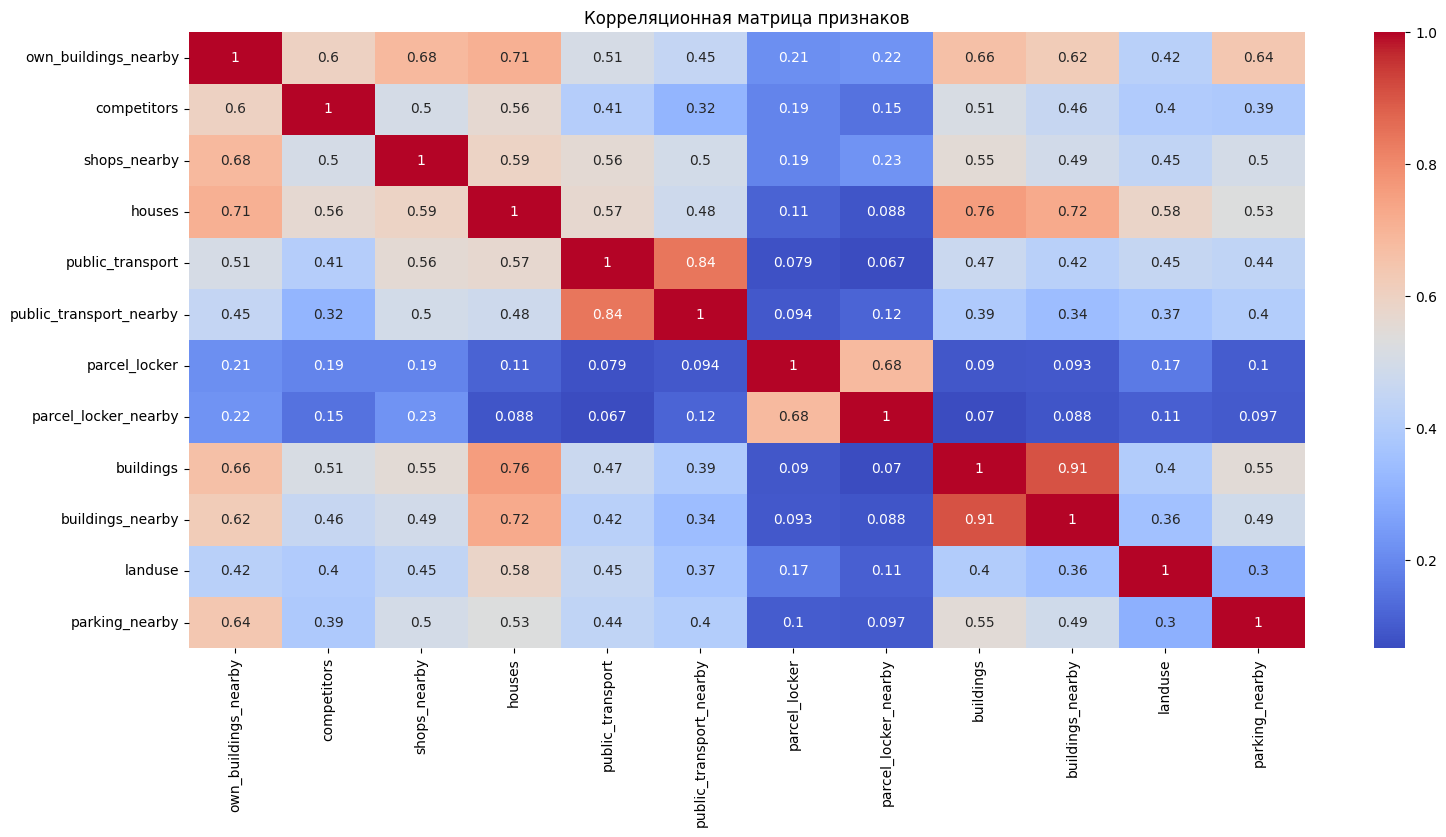

In [142]:
corr_mat = main_gdf[features].corr()
plt.figure(figsize=(18, 8))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица признаков')
plt.show()

   - Выявите и обработайте выбросы и пропущенные значения, если они имеются

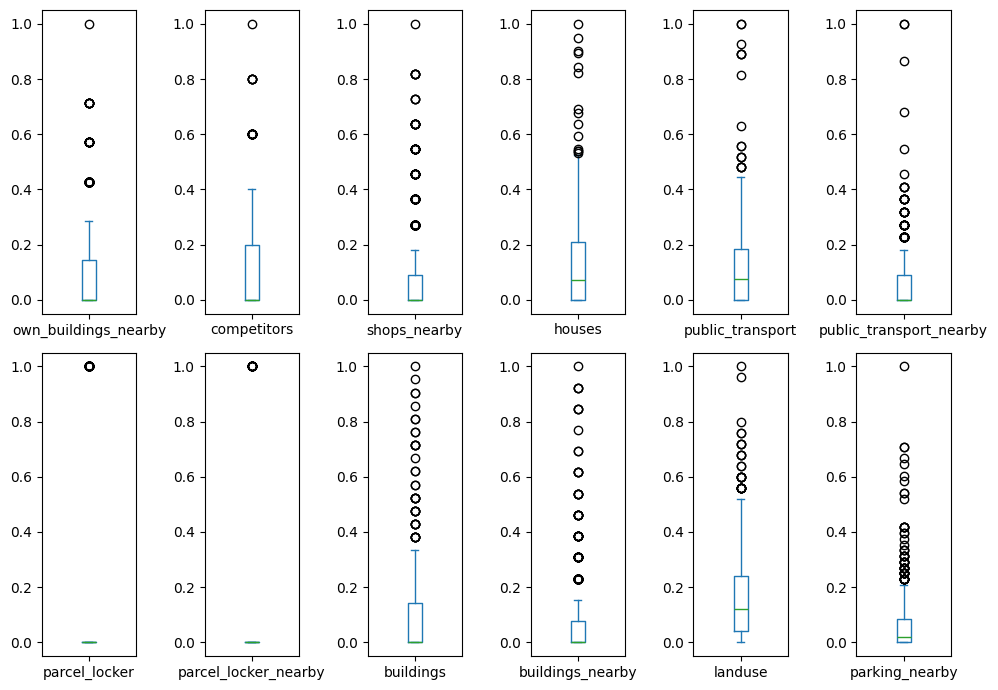

In [143]:
main_gdf[features].plot(kind='box', subplots=True, layout=(2, 6), figsize=(10, 7))
plt.tight_layout()

Подобные выбросы ожидаемы, т.к. изучались участки как и с плотными жилыми районами, так и такие, что находятся в промышленных или малонаселенных участках. Пропусков в данных нет, поэтому, не будем никак обрабатывать данные

### **Часть 3. Моделирование привлекательности локаций**



1. **Подготовка целевой переменной**:
   - Определите, как будет сформирована целевая переменная для вашей задачи (по умолчанию: наличие объектов выбранного типа в ячейке)


Будем считать следующим образом:

Вычитать баллы будем за наличие поблизости уже существующих своих ПВЗ (наибольший штраф) и чуть меньше за наличие поблизости конкурентов

За остальное действуем следующим образом:

- в "двойных" признаках (которые учитываются и на 300, и на 600 м) будем считать больше баллов за ближайщие объекты, вычитывать эти объекты из числа тех, что находятся дальше, и назначать меньше за дальние объекты

- больше всего баллов будем назначать за наличие жилых домов, транспортных остановок и иных зданий (детсадов, офисов, школ и т.д.) поблизости. За остальные - меньше

In [186]:
# можно было бы и через матричное умножение, если бы я не сделал "двойные" признаки
main_gdf['index_score'] = (
    (main_gdf['own_buildings_nearby'] * -0.7) +
    (main_gdf['competitors'] * -0.15) +
    (main_gdf['shops_nearby']* 0.15) +
    (main_gdf['houses'] * 0.2) +
    ((main_gdf['public_transport']-main_gdf['public_transport_nearby'])* 0.03) +
    (main_gdf['public_transport_nearby'] * 0.1) +
    ((main_gdf['parcel_locker']-main_gdf['parcel_locker_nearby'])* 0.03) +
    (main_gdf['parcel_locker_nearby'] * 0.15) +
    ((main_gdf['buildings'] - main_gdf['buildings_nearby']) * 0.1) +
    (main_gdf['buildings_nearby'] * 0.22) +
    ((main_gdf['landuse']-main_gdf['houses']) * 0.05) +
    (main_gdf['parking_nearby'] * 0.15)
    )*10
main_gdf['index_score'] = scaler.fit_transform(pd.DataFrame(main_gdf['index_score']))

   - Исследуйте распределение целевой переменной и оцените её сбалансированность

In [187]:
main_gdf['index_score'].describe()

,index_score
count,802.000000
mean,0.618118
std,0.128903
min,0.000000
25%,0.595121
50%,0.630737
75%,0.674985
max,1.000000


<Axes: >

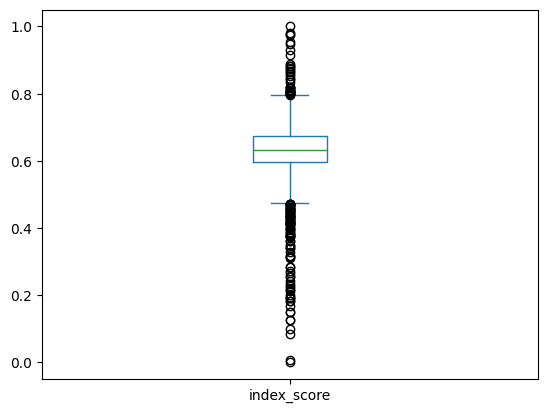

In [188]:
main_gdf['index_score'].plot(kind='box')

In [189]:
# Создаем карту
map_result = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=12, basemap='CartoDB.Positron')

# Добавляем H3 ячейки
map_result.add_data(
    main_gdf,
    column="index_score",
    cmap="OrRd",
    legend_title="index_score",
    k=20,
    layer_name="H3 Сетка",
    style={
        "stroke": True,     # или False
        "weight": 0,        # толщина обводки
        "fillOpacity": 0.7, # прозрачность заливки
    }
)

# Отображаем карту
map_result

Map(center=[np.float64(55.39283315), np.float64(37.5398555)], controls=(ZoomControl(options=['position', 'zoom…

   - При необходимости, предложите стратегию работы с несбалансированными данными

Необходимости не вижу, как уже описывал ранее, подобные выбросы и возможная несбалансированность ожидаемы, так как работаем с различными районами города

2. **Разработка моделей машинного обучения**:
   - Реализуйте и обучите несколько моделей (минимум 2) для предсказания привлекательности локации

In [192]:
X = main_gdf[features].copy()
y = main_gdf['index_score'].copy()

X_df = pd.DataFrame(X, columns=features)
X_df.index = main_gdf.index
y.index = main_gdf.index

print("Размерность набора данных:", X.shape)
X_df.head(10)

Размерность набора данных: (802, 12)


,own_buildings_nearby,competitors,shops_nearby,houses,public_transport,public_transport_nearby,parcel_locker,parcel_locker_nearby,buildings,buildings_nearby,landuse,parking_nearby
0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.00,0.000000
1,0.142857,0.0,0.090909,0.125000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.16,0.062500
2,0.142857,0.2,0.090909,0.256579,0.222222,0.227273,0.0,0.0,0.142857,0.153846,0.40,0.000000
3,0.285714,0.0,0.272727,0.407895,0.222222,0.136364,0.0,0.0,0.142857,0.076923,0.20,0.104167
4,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.12,0.000000
5,0.142857,0.4,0.000000,0.217105,0.148148,0.136364,0.0,0.0,0.000000,0.000000,0.08,0.083333
6,0.000000,0.0,0.000000,0.032895,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.04,0.000000
7,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.08,0.000000
8,0.000000,0.0,0.000000,0.000000,0.074074,0.045455,0.0,0.0,0.000000,0.000000,0.28,0.000000
9,0.571429,0.6,0.272727,0.447368,0.222222,0.090909,0.0,0.0,0.285714,0.384615,0.28,0.208333


In [217]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.4, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

   - Проведите оценку важности признаков для каждой модели

<Axes: title={'center': 'Важности признаков'}>

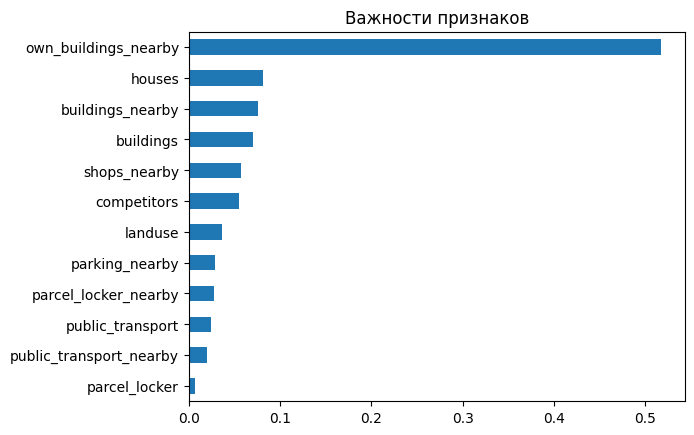

In [208]:
feat_imp = pd.Series(rf.feature_importances_, index=features)
feat_imp.sort_values().plot(kind='barh', title='Важности признаков')

<Axes: title={'center': 'Важности признаков (без own_buildings_nearby)'}>

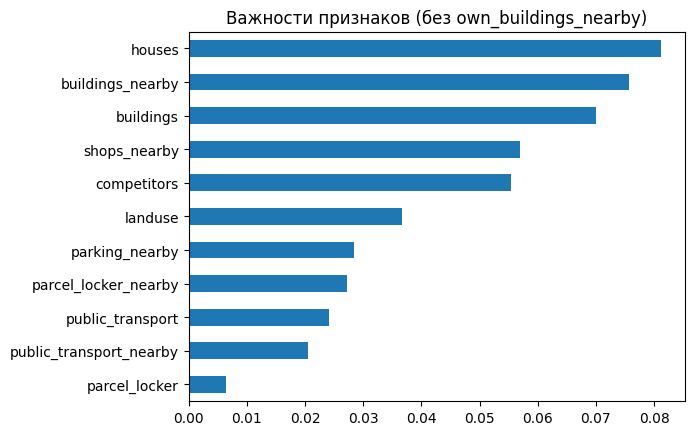

In [205]:
feat2= ['competitors', 'shops_nearby', 'houses', 'public_transport',
        'public_transport_nearby', 'parcel_locker', 'parcel_locker_nearby',
        'buildings', 'buildings_nearby', 'landuse', 'parking_nearby']
feat_imp[feat2].sort_values().plot(kind='barh', title='Важности признаков (без own_buildings_nearby)')

   - Сравните модели по метрикам качества и выберите наилучшую

In [219]:
results = []

r2_rf = r2_score(y_test, rf_pred)
mae_rf = mean_absolute_error(y_test, y_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred))
results.append({'Model': 'Random Forest', 'R2': r2_rf, 'MAE': mae_rf, 'RMSE': rmse_rf})


r2_gb = r2_score(y_test, gb_pred)
mae_gb = mean_absolute_error(y_test, y_pred)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred))
results.append({'Model': 'Gradient Boosting', 'R2': r2_gb, 'MAE': mae_gb, 'RMSE': rmse_gb})

pd.DataFrame(results).sort_values('R2', ascending=False)

,Model,R2,MAE,RMSE
1,Gradient Boosting,0.894746,0.02118,0.0378
0,Random Forest,0.838365,0.02118,0.0378


   - **Дополнительное задание**: настройте гиперпараметры модели с помощью поиска по сетке (GridSearchCV) или случайного поиска (RandomSearchCV)

In [226]:
from sklearn.model_selection import GridSearchCV

n_estimators = [int(x) for x in range(50, 300, 25)]
learning_rate = np.arange(0.1, 2.0, 0.2)
max_depth = [int(x) for x in range(1, 8)]
max_depth.append(None)

param_grid = {
    'n_estimators': n_estimators
}

param2_grid = {
    'n_estimators': n_estimators,
    'learning_rate': learning_rate,
    'max_depth': max_depth
}

rf_cv = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, verbose=1, n_jobs=-1)
rf_cv.fit(X_train, y_train)
gb_cv = GridSearchCV(estimator=gb, param_grid=param2_grid, cv=5, verbose=1, n_jobs=-1)
gb_cv.fit(X_train, y_train)

best_params_rf = rf_cv.best_params_
best_model_rf = rf_cv.best_estimator_
r2_best_rf = r2_score(y_test, best_model_rf.predict(X_test))

best_params_gb = gb_cv.best_params_
best_model_gb = gb_cv.best_estimator_
r2_best_gb = r2_score(y_test, best_model_gb.predict(X_test))

print(f"Лучшие параметры Random Forest: {best_params_rf}; R2: {r2_best_rf}")
print(f"Лучшие параметры Gradient Boosting: {best_params_gb}; R2: {r2_best_gb}")

Лучшие параметры Random Forest: {'n_estimators': 100}; R2: 0.8383652183595836
Лучшие параметры Gradient Boosting: {'learning_rate': np.float64(0.9000000000000001), 'max_depth': 1, 'n_estimators': 275}; R2: 0.980163962570764


3. **Улучшение модели с помощью кластеризации**:
   - Выполните кластеризацию ячеек по их характеристикам


   - Определите оптимальное число кластеров с помощью метода локтя или силуэта

In [215]:
%%capture
!pip install kneed

Оценка для k=2...
Оценка для k=3...
Оценка для k=4...
Оценка для k=5...
Оценка для k=6...
Оценка для k=7...
Оценка для k=8...
Оценка для k=9...
Оценка для k=10...
Оценка для k=11...
Оценка для k=12...


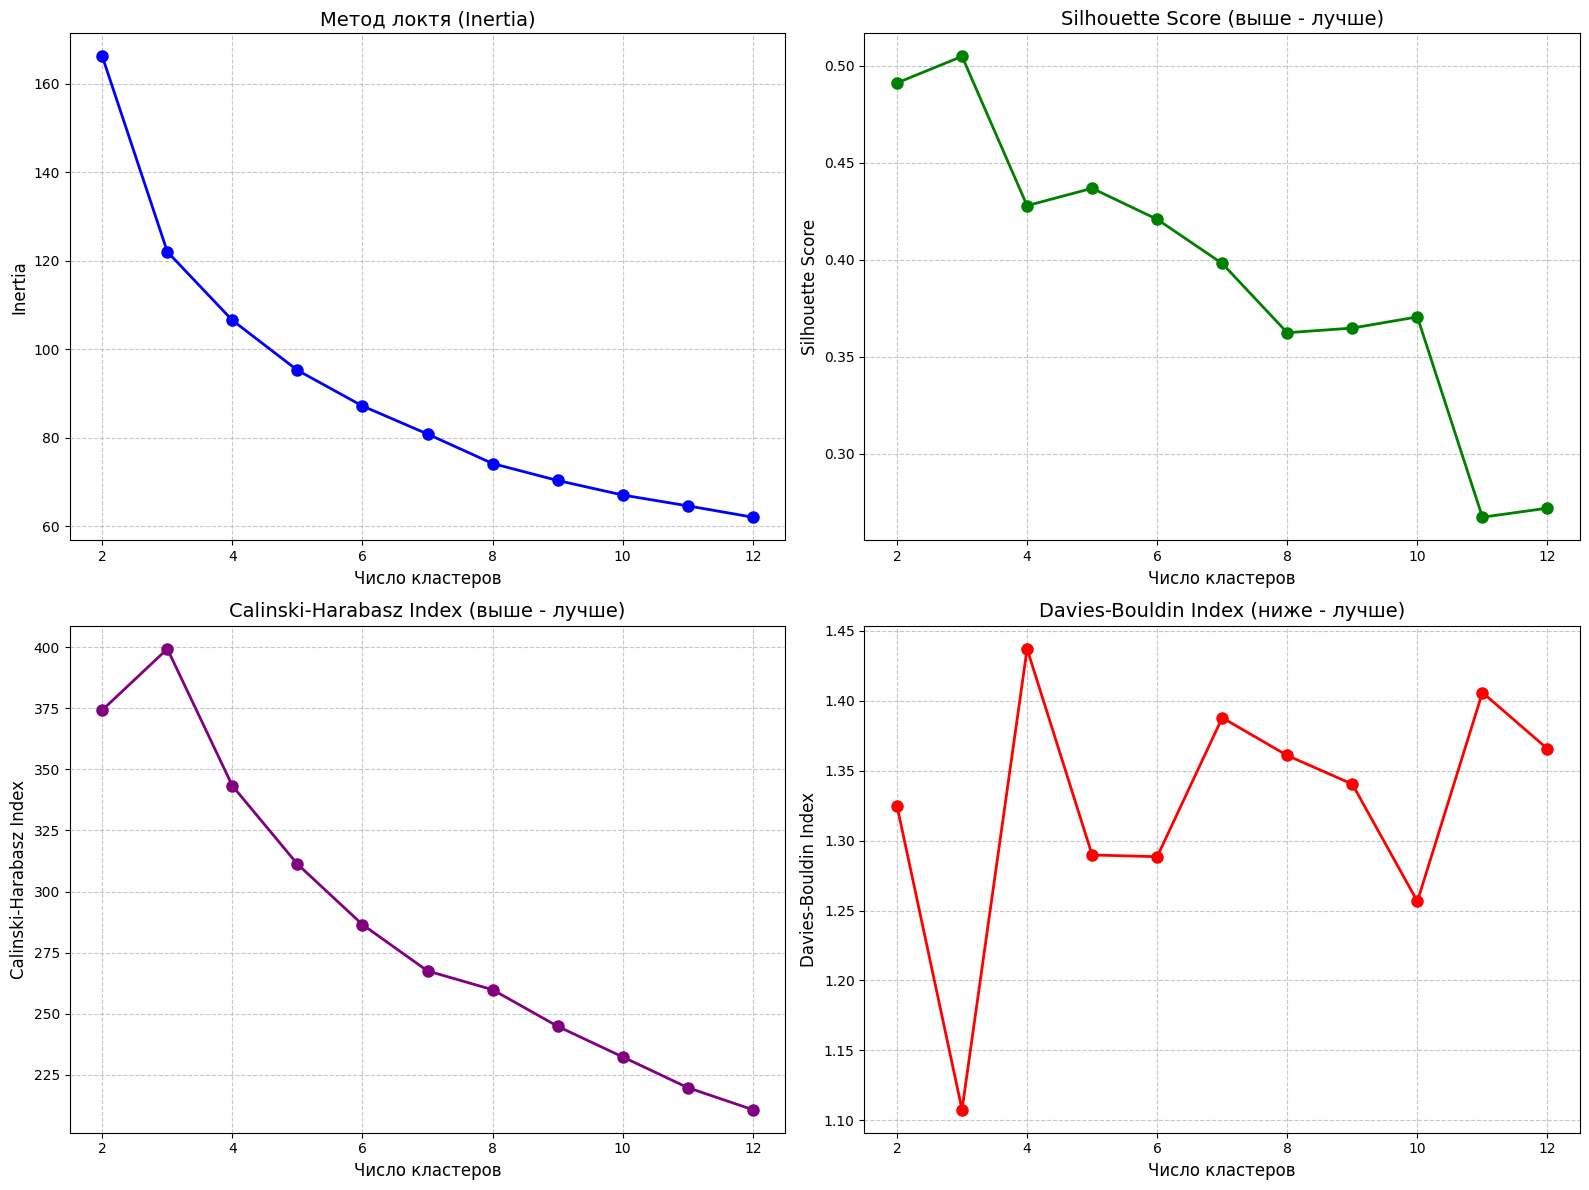


Оптимальное число кластеров по разным метрикам:
Метод локтя (Inertia): 5
Silhouette Score: 3
Calinski-Harabasz Index: 3
Davies-Bouldin Index: 3

Таблица со значениями метрик:


,Число кластеров,Inertia,Silhouette Score,Calinski-Harabasz,Davies-Bouldin
0,2,166.207848,0.491250,374.271684,1.324841
1,3,122.015232,0.504933,399.290443,1.107681
2,4,106.514019,0.427995,343.263265,1.436944
3,5,95.223095,0.436930,311.238738,1.289685
4,6,87.142720,0.420941,286.499434,1.288456
5,7,80.803494,0.398185,267.551467,1.387735
6,8,74.129845,0.362498,259.872723,1.360776
7,9,70.294671,0.364893,244.900728,1.340291
8,10,67.011661,0.370647,232.377803,1.256522
9,11,64.558622,0.267417,219.818201,1.405753


In [216]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
from kneed import KneeLocator

def find_optimal_clusters(X, max_k=8):
    """
    Определение оптимального числа кластеров с помощью различных метрик
    """
    # Метрики для оценки качества кластеризации
    inertias = []  # Для метода локтя
    silhouette_scores = []  # Silhouette Score
    calinski_scores = []  # Calinski-Harabasz Index
    davies_scores = []  # Davies-Bouldin Index

    # Вычисляем значения метрик для разного числа кластеров
    k_range = range(2, max_k + 1)
    for k in k_range:
        print(f"Оценка для k={k}...")
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)

        labels = kmeans.labels_
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, labels))
        calinski_scores.append(calinski_harabasz_score(X, labels))
        davies_scores.append(davies_bouldin_score(X, labels))

    # Визуализация результатов
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Метод локтя (Inertia)
    axes[0, 0].plot(k_range, inertias, 'o-', color='blue', linewidth=2, markersize=8)
    axes[0, 0].set_xlabel('Число кластеров', fontsize=12)
    axes[0, 0].set_ylabel('Inertia', fontsize=12)
    axes[0, 0].set_title('Метод локтя (Inertia)', fontsize=14)
    axes[0, 0].grid(True, linestyle='--', alpha=0.7)

    # Silhouette Score (чем выше, тем лучше)
    axes[0, 1].plot(k_range, silhouette_scores, 'o-', color='green', linewidth=2, markersize=8)
    axes[0, 1].set_xlabel('Число кластеров', fontsize=12)
    axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
    axes[0, 1].set_title('Silhouette Score (выше - лучше)', fontsize=14)
    axes[0, 1].grid(True, linestyle='--', alpha=0.7)

    # Calinski-Harabasz Index (чем выше, тем лучше)
    axes[1, 0].plot(k_range, calinski_scores, 'o-', color='purple', linewidth=2, markersize=8)
    axes[1, 0].set_xlabel('Число кластеров', fontsize=12)
    axes[1, 0].set_ylabel('Calinski-Harabasz Index', fontsize=12)
    axes[1, 0].set_title('Calinski-Harabasz Index (выше - лучше)', fontsize=14)
    axes[1, 0].grid(True, linestyle='--', alpha=0.7)

    # Davies-Bouldin Index (чем ниже, тем лучше)
    axes[1, 1].plot(k_range, davies_scores, 'o-', color='red', linewidth=2, markersize=8)
    axes[1, 1].set_xlabel('Число кластеров', fontsize=12)
    axes[1, 1].set_ylabel('Davies-Bouldin Index', fontsize=12)
    axes[1, 1].set_title('Davies-Bouldin Index (ниже - лучше)', fontsize=14)
    axes[1, 1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # Находим оптимальное число кластеров по разным метрикам

    # Метод локтя (Inertia)
    kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
    optimal_k_inertia = kl.elbow if kl.elbow is not None else "Не определено"

    # Silhouette Score (максимальное значение)
    optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]

    # Calinski-Harabasz (максимальное значение)
    optimal_k_calinski = k_range[np.argmax(calinski_scores)]

    # Davies-Bouldin (минимальное значение)
    optimal_k_davies = k_range[np.argmin(davies_scores)]

    print("\nОптимальное число кластеров по разным метрикам:")
    print(f"Метод локтя (Inertia): {optimal_k_inertia}")
    print(f"Silhouette Score: {optimal_k_silhouette}")
    print(f"Calinski-Harabasz Index: {optimal_k_calinski}")
    print(f"Davies-Bouldin Index: {optimal_k_davies}")

    # Создаем таблицу со значениями метрик
    metrics_df = pd.DataFrame({
        'Число кластеров': list(k_range),
        'Inertia': inertias,
        'Silhouette Score': silhouette_scores,
        'Calinski-Harabasz': calinski_scores,
        'Davies-Bouldin': davies_scores
    })

    print("\nТаблица со значениями метрик:")
    display(metrics_df)

    return {
        'inertia': optimal_k_inertia if optimal_k_inertia != "Не определено" else None,
        'silhouette': optimal_k_silhouette,
        'calinski': optimal_k_calinski,
        'davies': optimal_k_davies,
        'metrics_df': metrics_df
    }

optimal_clusters = find_optimal_clusters(X_scaled, max_k=12)

   - Визуализируйте результаты кластеризации

   - Проверьте, улучшает ли добавление информации о кластерах качество основной модели

### **Часть 4. Расчет потенциала локаций и финальные рекомендации**



1. **Разработка интегрального показателя потенциала**:
   - Самостоятельно определите веса для факторов привлекательности среды и конкуренции

уже сделано ранее

   - Рассчитайте итоговый потенциал для всех ячеек сетки

   - Категоризируйте потенциал для упрощения интерпретации результатов

   - Обоснуйте выбранные веса в контексте вашего бизнеса

уже сделано ранее

2. **Визуализация результатов**:
   - Создайте интерактивную карту с тепловым слоем потенциала

   - Добавьте маркеры существующих объектов вашего типа бизнеса

   - Выделите топ-10 локаций с наивысшим потенциалом

   - Подготовьте отдельную карту фокуса на лучших локациях

3. **Формирование бизнес-рекомендаций**:
   - Составьте список из 5-7 конкретных локаций для размещения новых объектов

   - Для каждой рекомендуемой локации укажите:
     * Точные координаты
     * Значение потенциала
     * Ключевые характеристики локации
     * Преимущества и возможные риски размещения в данной точке

   - Подготовьте общие рекомендации по стратегии территориального развития для выбранного бизнеса

## **Рекомендации по выполнению**


1. Начните с малой территории для тестирования кода и методологии, затем расширяйте анализ.
2. Используйте инкрементальный подход: сначала реализуйте базовый функционал, затем улучшайте его.
3. Регулярно сохраняйте промежуточные результаты работы.
4. При выборе признаков опирайтесь не только на учебный материал, но и на научные статьи по геоанализу и геомаркетингу.
5. Обращайте внимание на особенности территории и уникальные характеристики выбранного бизнеса.
6. Для оценки результатов старайтесь сопоставить их с реальным расположением успешных объектов аналогичного бизнеса.